# Taken the House Prices - Advanced Regression Techniques

step1: Load & Preprocess Data

In [52]:
# imports
import pandas as pd
import numpy as np

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from Codespace import file_paths

In [53]:
# Loading the data
df = pd.read_csv(file_paths.HOUSE_PRICES_PATH)
df.shape


(1460, 81)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [55]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [56]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [57]:
# If we see the info() - 43 columns are Text
# so we will check for missing values
missing = df.isnull().sum().sort_values(ascending=True)
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_percent})
print(missing_df[missing_df["Missing Count"] > 0])

              Missing Count  Percentage
Electrical                1    0.068493
MasVnrArea                8    0.547945
BsmtFinType1             37    2.534247
BsmtQual                 37    2.534247
BsmtCond                 37    2.534247
BsmtFinType2             38    2.602740
BsmtExposure             38    2.602740
GarageQual               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageType               81    5.547945
GarageCond               81    5.547945
LotFrontage             259   17.739726
FireplaceQu             690   47.260274
MasVnrType              872   59.726027
Fence                  1179   80.753425
Alley                  1369   93.767123
MiscFeature            1406   96.301370
PoolQC                 1453   99.520548


In [58]:
# Highest was PoolQC 99%

# now we check for duplicates
df.duplicated().sum()

np.int64(0)

In [59]:
# atleast no duplicates are there

In [60]:
# checking the correlation
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
correlations.head(10)

# corelation closer to 1 is strong but closer to 0 is weak
# highest is 0.79

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [61]:
# handle the missing values  - Missing means "feature doesn't exist" — fill with 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish',
            'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'BsmtCond', 'BsmtQual', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna(0)

In [62]:
# Numeric columns where missing also means "doesn't exist" — fill with 0
zero_cols = ['GarageYrBlt', 'MasVnrArea']
for col in zero_cols:
    df[col] = df[col].fillna(0)

In [63]:
# missing likely means irregular lot shape, fill with median
df['LotFrontage'] = df["LotFrontage"].fillna(df["LotFrontage"].median())
# Median is safer than mean here since price-like values are often skewed by outliers.

In [64]:
# Electrical — only 1 missing, just drop that row
df = df.dropna(subset=["Electrical"])

In [65]:
# checking again
df.isnull().sum().sum()

np.int64(0)

Now we'll try to train and split the data using the sickit-learn

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice", "Id"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape:  (1167, 79)
Test shape:  (292, 79)


In [67]:
"""
 we should not treat all missing data in the same way
 Does missing mean unknown, or it means doesn't exist?
 Then we have to fill the column with None or 0, fill with median/mean or drop the row
"""

"\n we should not treat all missing data in the same way\n Does missing mean unknown, or it means doesn't exist?\n Then we have to fill the column with None or 0, fill with median/mean or drop the row\n"

Step 2: Feature Engineering

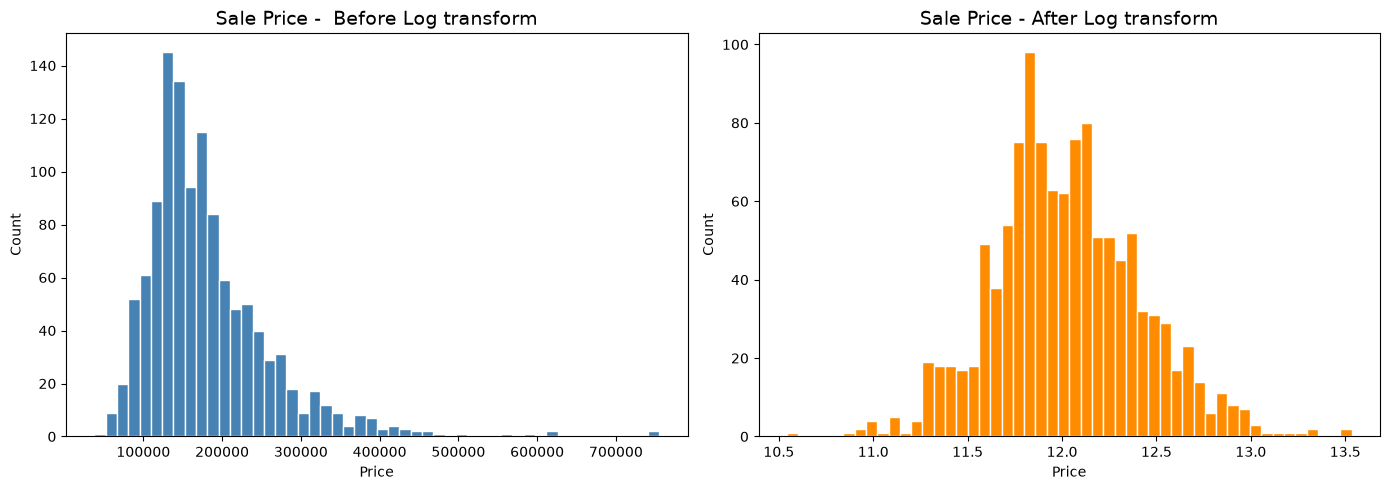

In [68]:
"""
This step answers one question: which of the features help predict those prices, and which are noise?
 we have 79 columns, giving all of them to the model is actually worse than selecting the best ones.
 Irrelevant featues add noise and slow training.
"""
# 1. Check and Fix SalePrices Skewness
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price -  Before Log transform', fontsize=14)
axes[0].set_xlabel('Price')
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(y_train), bins=50, color='darkorange', edgecolor="white")
axes[1].set_title("Sale Price - After Log transform", fontsize=14)
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [69]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [70]:
# 2 Encode categorial columns

# Ordinal categories  → Label Encoding
# Nominal categories  → One-Hot Encoding

# i) Label encode oridinal quality columns

from sklearn.preprocessing import LabelEncoder

ordinal_columns= [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual',
    'GarageCond', 'PoolQC'
]

le = LabelEncoder()

for col in ordinal_columns:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))



In [71]:
# ii) One-hot encoding nominal columns

nominal_columns = X_train.select_dtypes(include="object").columns.tolist()
print(f"Nominal columns to one-hot encode: {len(nominal_columns)}")

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train = pd.get_dummies(X_train, columns=nominal_columns)
X_test = pd.get_dummies(X_test, columns=nominal_columns)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("shape after encoding ", X_train.shape)

Nominal columns to one-hot encode: 33
shape after encoding  (1167, 259)


/tmp/ipykernel_135253/2367700100.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_columns = X_train.select_dtypes(include="object").columns.tolist()


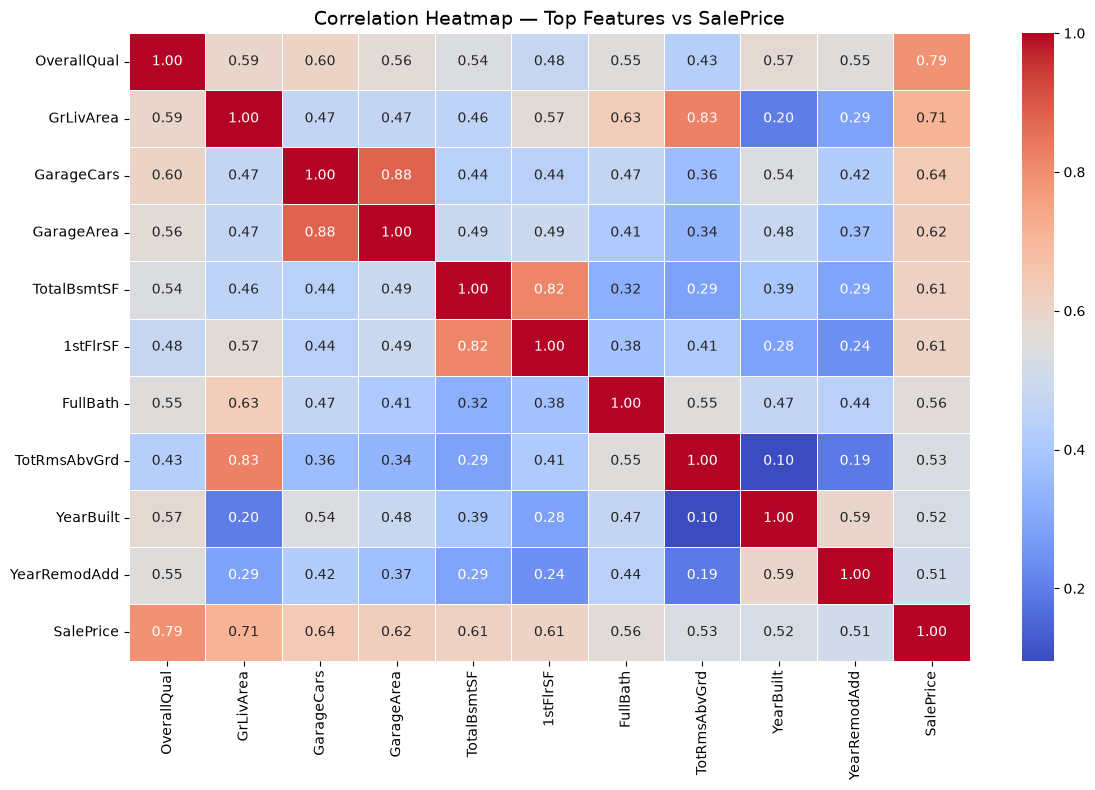

In [72]:
# Finding important Featues, drop irrevelant ones

# Correlation of top numeric features

# i) Select top correlated numeric features
top_corr_cols = correlations[1:11].index.tolist()  # top 10 excluding SalePrice itself
top_corr_cols.append('SalePrice')

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top Features vs SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

In [73]:
# ii) Low-varience features and drop them

from sklearn.feature_selection import VarianceThreshold

# Drop columns where almost every value is the same
# (these teach the model nothing)
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

low_variance_cols = X_train.columns[~selector.get_support()].tolist()
print(f"Low variance columns to drop: {len(low_variance_cols)}")
print(low_variance_cols[:10])  # preview first 10

X_train = X_train[X_train.columns[selector.get_support()]]
X_test  = X_test[X_train.columns]

print("Shape after variance filter:", X_train.shape)

Low variance columns to drop: 71
['MSZoning_C (all)', 'Street_Grvl', 'Street_Pave', 'LotShape_IR3', 'Utilities_AllPub', 'Utilities_NoSeWa', 'LotConfig_FR3', 'LandSlope_Sev', 'Neighborhood_Blmngtn', 'Neighborhood_Blueste']
Shape after variance filter: (1167, 188)


In [74]:
# iii) drop highely correlated features ~ to avoid multicollinearity

# Find pairs of features that are too similar to each other
correlation_matrix = X_train.corr().abs()

# Get upper triangle only (avoid counting pairs twice)
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Drop one from each pair with correlation > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Highly correlated columns to drop: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop, errors='ignore')

print("Final shape:", X_train.shape)

Highly correlated columns to drop: 9
['Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'BsmtFinType1_0', 'BsmtFinType2_0', 'CentralAir_Y', 'GarageType_0', 'GarageFinish_0', 'SaleCondition_Partial']
Final shape: (1167, 179)


In [75]:
# iv) Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
print(f"Started with:   79 features")
print(f"After encoding: 259 features")
print(f"After variance: 188 features")
print(f"After corr drop: 179 features")
print(f"Final features going into models: {X_train.shape[1]}")

Started with:   79 features
After encoding: 259 features
After variance: 188 features
After corr drop: 179 features
Final features going into models: 179


# Step 3 Train 3 different models

In [77]:
# here we have to try with three differnet models
# and take the cleand and featured data 

In [78]:
# let's try with linear regression, decision tree and randomforest regression algorithms
# all imports
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [79]:
# lets see the Linear Regression
lr_model = LinearRegression()
# this will try to create a model object with default settings. (It founds straight line through the data mathematically)
lr_model.fit(X_train_scaled, y_train_log)
# training is using .fit() 



# let's check the coefficient for the lr_model
coefficients = pd.Series(
    lr_model.coef_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 5 Features: (positive)")
print(coefficients.head())
print("\nTop 5 Features: (negative)")
print(coefficients.tail())

Top 5 Features: (positive)
MSZoning_RL         0.077819
PoolArea            0.076094
OverallQual         0.057713
BsmtFinType1_GLQ    0.055614
GrLivArea           0.055005
dtype: float64

Top 5 Features: (negative)
HouseStyle_2Story   -0.029100
GarageFinish_Fin    -0.039921
GarageFinish_RFn    -0.046573
GarageFinish_Unf    -0.055258
PoolQC              -0.087002
dtype: float64


In [84]:
# 2 Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
# if you are not using the max_depth the values will be very close or much to be 1
# min_samples_split=5 - a node must have atleast 5 houses before its split
# min_samples_leaf=3 - every final leaf must contain atleast 3 houses. 
# random_state - makes the results reproducible
dt_model.fit(X_train, y_train_log)

# now we will try to find the correlation values
correlations = pd.Series(
    dt_model.feature_importances_, # in dt no coef__ 
    index=X_train.columns
).sort_values(ascending=False)
print("Top 5 Features: (positive)")
print(coefficients.head())
print("\nTop 5 Features: (negative)")
print(coefficients.tail())

Top 5 Features: (positive)
MSZoning_RL         0.077819
PoolArea            0.076094
OverallQual         0.057713
BsmtFinType1_GLQ    0.055614
GrLivArea           0.055005
dtype: float64

Top 5 Features: (negative)
HouseStyle_2Story   -0.029100
GarageFinish_Fin    -0.039921
GarageFinish_RFn    -0.046573
GarageFinish_Unf    -0.055258
PoolQC              -0.087002
dtype: float64


In [88]:
# 3 Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train_log)
# n_estimators=200 - how many trees to build. Each tree trains on a random sample of houses and a random subset of features
# max_depth=15 - each individual tree can go deeper than our single Decision Tree 
# min_samples_split=5 and min_samples_leaf=3 — same meaning as Decision Tree, same purpose.
# max_features='sqrt' - this is the key ingredient that makes Random Forest work. When building each split, it only looks at a random square root of features
# Example: sqrt(184) = 14 (~)
# n_jobs=-1 — use all available CPU cores to train trees in parallel. With 200 trees this matters

correlations = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print("Top 5 Features: (positive)")
print(coefficients.head())
print("\nTop 5 Features: (negative)")
print(coefficients.tail())

Top 5 Features: (positive)
MSZoning_RL         0.077819
PoolArea            0.076094
OverallQual         0.057713
BsmtFinType1_GLQ    0.055614
GrLivArea           0.055005
dtype: float64

Top 5 Features: (negative)
HouseStyle_2Story   -0.029100
GarageFinish_Fin    -0.039921
GarageFinish_RFn    -0.046573
GarageFinish_Unf    -0.055258
PoolQC              -0.087002
dtype: float64


In [90]:
# Making all predictions for the three models

# Linear Regression (was trained on scaled data)
lr_pred_log  = lr_model.predict(X_test_scaled)

# Decision Tree and Random Forest (trained on unscaled data)
dt_pred_log  = dt_model.predict(X_test)
rf_pred_log  = rf_model.predict(X_test)

# Reverse the log transform to get back to real dollar amounts
lr_pred  = np.expm1(lr_pred_log)
dt_pred  = np.expm1(dt_pred_log)
rf_pred  = np.expm1(rf_pred_log)
y_actual = np.expm1(y_test_log)

print("Sample predictions vs actual (first 5 houses):")
comparison = pd.DataFrame({
    'Actual':          y_actual.values[:5],
    'Linear Reg':      lr_pred[:5].round(0),
    'Decision Tree':   dt_pred[:5].round(0),
    'Random Forest':   rf_pred[:5].round(0)
})
print(comparison)

Sample predictions vs actual (first 5 houses):
     Actual  Linear Reg  Decision Tree  Random Forest
0  164700.0    168946.0       186439.0       163714.0
1  116000.0    132584.0       119302.0       125996.0
2  266000.0    273255.0       299052.0       274235.0
3  258000.0    246450.0       204563.0       264526.0
4   72500.0     78049.0        94434.0        93681.0


In [92]:
# sanitation checks on 3 models
from sklearn.metrics import r2_score

print("Training R2 scores (higher = model learned more from training data):")
print(f"Linear Regression : {r2_score(y_train_log, lr_model.predict(X_train_scaled)):.4f}")
print(f"Decision Tree     : {r2_score(y_train_log, dt_model.predict(X_train)):.4f}")
print(f"Random Forest     : {r2_score(y_train_log, rf_model.predict(X_train)):.4f}")

print("\nTest R2 scores (this is what actually matters):")
print(f"Linear Regression : {r2_score(y_test_log, lr_pred_log):.4f}")
print(f"Decision Tree     : {r2_score(y_test_log, dt_pred_log):.4f}")
print(f"Random Forest     : {r2_score(y_test_log, rf_pred_log):.4f}")

Training R2 scores (higher = model learned more from training data):
Linear Regression : 0.9235
Decision Tree     : 0.9604
Random Forest     : 0.9354

Test R2 scores (this is what actually matters):
Linear Regression : 0.8922
Decision Tree     : 0.7599
Random Forest     : 0.8419


In [93]:
# The gap between training and test R² is called the overfitting gap. Decision Tree has the biggest gap